# BIRD-CRITIC 1.0 Open — result figures

Every number is read from the run artefacts on disk; nothing is hardcoded, so re-running
this notebook after a new run regenerates the figures against the new data.

**Coverage caveat that applies to every figure below:** 472 of 570 instances. The 98 Oracle
instances are missing because `3036197201/oracle19` is published arm64-only and this host is
x86_64. These are partial-coverage numbers and are **not** comparable to the public leaderboard,
which scores all 570 with a different model and re-runs submissions in BIRD's own environment.

Runs used:

| Run | Setting |
|---|---|
| `full_nocap_20260812` | no `max_tokens` sent |
| `full_cap512_20260817` | `max_tokens=512` — upstream's undocumented default |
| `loop_k3_pg60` | k=3 execution-feedback loop, first 60 PostgreSQL instances |

In [1]:
import json
import re
from collections import Counter
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

BASE = Path.cwd().parent if Path.cwd().name == "analysis" else Path(".")
OUT = BASE / "analysis" / "figures"
OUT.mkdir(parents=True, exist_ok=True)

# ---- Palette -------------------------------------------------------------
# Validated categorical slots 1-3 (all-pairs clean in light mode:
# worst CVD dE 9.2, worst normal-vision dE 27.6). Slot 3 aqua sits below 3:1
# against the surface, so every mark carries a visible value label -- that is
# the required relief, not decoration.
S1, S2, S3 = "#2a78d6", "#eb6834", "#1baf7a"   # blue, orange, aqua
STATUS_GOOD, STATUS_CRIT = "#0ca30c", "#d03b3b"
SURFACE   = "#fcfcfb"
INK       = "#0b0b0b"
INK_2     = "#52514e"
MUTED     = "#898781"
GRID      = "#e1e0d9"
BASELINE  = "#c3c2b7"
# Sequential blue, ordinal-safe steps (>=2:1 on light surface, so no step
# recedes into the background).
SEQ = ["#86b6ef", "#5598e7", "#3987e5", "#256abf", "#184f95"]

mpl.rcParams.update({
    "figure.facecolor": SURFACE,
    "axes.facecolor": SURFACE,
    "savefig.facecolor": SURFACE,
    "font.family": ["Segoe UI", "DejaVu Sans", "sans-serif"],
    "font.size": 10,
    "axes.edgecolor": BASELINE,
    "axes.labelcolor": INK_2,
    "axes.titlecolor": INK,
    "axes.titlesize": 12,
    "axes.titleweight": "600",
    "axes.titlelocation": "left",
    "axes.titlepad": 14,
    "xtick.color": MUTED,
    "ytick.color": MUTED,
    "xtick.labelcolor": INK_2,
    "ytick.labelcolor": INK_2,
    "grid.color": GRID,
    "grid.linewidth": 0.8,
    "legend.frameon": False,
    "legend.fontsize": 9,
    "lines.linewidth": 2,
    "figure.dpi": 110,
})


def frame(ax, xgrid=True):
    """Recessive chrome: no box, hairline grid on the value axis only."""
    for side in ("top", "right", "left" if xgrid else "bottom"):
        ax.spines[side].set_visible(False)
    ax.spines["bottom" if xgrid else "left"].set_color(BASELINE)
    ax.set_axisbelow(True)
    ax.grid(axis="x" if xgrid else "y")
    ax.tick_params(length=0)


def save(fig, name):
    fig.savefig(OUT / f"{name}.png", bbox_inches="tight", dpi=200)
    print(f"saved -> analysis/figures/{name}.png")


print("base:", BASE.resolve())

base: C:\research\MAS\paper\SCM\baselines\text2sql\23_bird_critic


In [2]:
# ---- Loaders -------------------------------------------------------------

DIALECTS = ["PostgreSQL", "MySQL", "SQLServer"]
FILE_STEM = {"PostgreSQL": "postgresql", "MySQL": "mysql", "SQLServer": "sqlserver"}


def jsonl(path):
    with open(path, encoding="utf-8") as fh:
        return [json.loads(l) for l in fh if l.strip()]


def load_status(run):
    """instance_id -> 'success' | 'failed', from the harness."""
    out = {}
    for p in (BASE / "data" / "outputs" / run / "status").glob("*_output_with_status.jsonl"):
        for r in jsonl(p):
            out[r["instance_id"]] = r.get("status")
    return out


def load_gen(run):
    """instance_id -> generation record (usage, truncation, dialect, category)."""
    out = {}
    for p in (BASE / "data" / "outputs" / run).glob("*_inter.jsonl"):
        for r in jsonl(p):
            out[r["instance_id"]] = r
    return out


def load_phase(run):
    """instance_id -> execution | assertion | timeout.

    Parsed from the harness report. Coverage is uneven by design: upstream labels
    every PostgreSQL failure, only execution errors for SQL Server, and nothing
    per-instance for MySQL -- so any figure using this must say which dialect it
    covers rather than implying all three.
    """
    out = {}
    for p in (BASE / "data" / "outputs" / run / "status").glob("*_report.txt"):
        for line in open(p, encoding="utf-8"):
            m = re.match(r"Question_(\S+?):", line.strip())
            if not m:
                continue
            if "Execution Error" in line:
                out[m.group(1)] = "execution"
            elif "Assertion Error" in line:
                out[m.group(1)] = "assertion"
            elif "Timeout" in line:
                out[m.group(1)] = "timeout"
    return out


def report_totals(run, dialect):
    """Header block of the harness report -- the authoritative per-dialect counts."""
    p = BASE / "data" / "outputs" / run / "status" / f"fn_{FILE_STEM[dialect]}_report.txt"
    if not p.exists():
        p = BASE / "data" / "outputs" / run / "status" / f"c512_{FILE_STEM[dialect]}_report.txt"
    txt = p.read_text(encoding="utf-8")[:800]
    grab = lambda k: int(re.search(rf"{k}: (\d+)", txt).group(1))
    n = grab("Number of Instances")
    return {
        "n": n,
        "execution": grab("Number of Execution Errors"),
        "timeout": grab("Number of Timeouts"),
        "assertion": grab("Number of Assertion Errors"),
        "accuracy": float(re.search(r"Overall Accuracy: ([\d.]+)", txt).group(1)),
    }


NOCAP, CAP = "full_nocap_20260812", "full_cap512_20260817"
st_nocap, st_cap = load_status(NOCAP), load_status(CAP)
gen_nocap, gen_cap = load_gen(NOCAP), load_gen(CAP)
phase_nocap = load_phase(NOCAP)

ids = sorted(set(st_nocap) & set(st_cap))
ok = lambda st, i: st.get(i) == "success"

print(f"paired instances: {len(ids)}")
print(f"nocap  {sum(ok(st_nocap, i) for i in ids)}/{len(ids)}")
print(f"cap512 {sum(ok(st_cap, i) for i in ids)}/{len(ids)}")

paired instances: 472
nocap  131/472
cap512 136/472


## Fig 1 — Success rate by dialect

Two settings, three dialects. Grouped bars: the job is magnitude comparison, and the
grouping keeps each dialect's pair adjacent so the within-dialect delta is the short
visual distance.

findfont: Failed to find font weight 600, now using 700.


findfont: Failed to find font weight 600, now using 700.


saved -> analysis/figures/fig01_sr_by_dialect.png


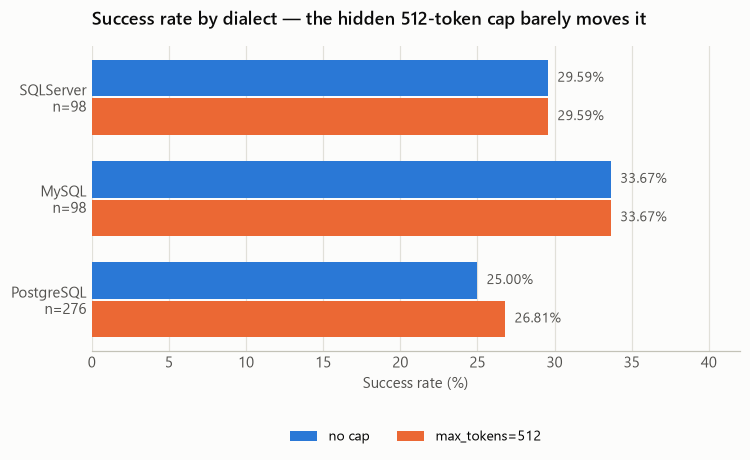

In [3]:
rows = []
for d in DIALECTS:
    a, b = report_totals(NOCAP, d), report_totals(CAP, d)
    rows.append((d, a["n"], a["accuracy"], b["accuracy"]))

labels = [f"{d}\nn={n}" for d, n, _, _ in rows]
y = np.arange(len(rows))
h = 0.36
gap = 0.02          # 2px-equivalent surface gap between adjacent fills

fig, ax = plt.subplots(figsize=(7.6, 3.6))
b1 = ax.barh(y + (h + gap) / 2, [r[2] for r in rows], h, color=S1, label="no cap")
b2 = ax.barh(y - (h + gap) / 2, [r[3] for r in rows], h, color=S2, label="max_tokens=512")

for bars in (b1, b2):
    for bar in bars:
        w = bar.get_width()
        ax.text(w + 0.6, bar.get_y() + bar.get_height() / 2, f"{w:.2f}%",
                va="center", fontsize=9, color=INK_2)

ax.set_yticks(y, labels)
ax.set_xlim(0, 42)
ax.set_xlabel("Success rate (%)")
ax.set_title("Success rate by dialect — the hidden 512-token cap barely moves it")
# Below the axis, matching the other figures. In-frame it crowded the value labels.
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.22), ncols=2)
frame(ax)
save(fig, "fig01_sr_by_dialect")
plt.show()

## Fig 2 — What failure looks like

Composition per dialect, so stacked. Absolute counts rather than percentages because n
differs threefold across dialects and the counts are the quantity later analysis works on.

`assertion` is the harness's label, and it is broader than "wrong result": the test-case
code raising *any* exception lands here too, not only a failed `assert`.

findfont: Failed to find font weight 600, now using 700.


findfont: Failed to find font weight 600, now using 700.


saved -> analysis/figures/fig02_failure_composition.png


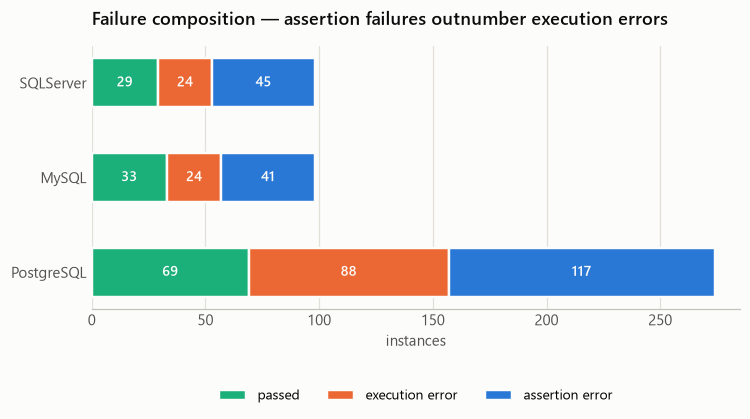

total: passed=131  execution=136  assertion=203


In [4]:
tot = {d: report_totals(NOCAP, d) for d in DIALECTS}
passed = [tot[d]["n"] - tot[d]["execution"] - tot[d]["assertion"] - tot[d]["timeout"] for d in DIALECTS]
execs = [tot[d]["execution"] for d in DIALECTS]
asserts = [tot[d]["assertion"] for d in DIALECTS]

y = np.arange(len(DIALECTS))
fig, ax = plt.subplots(figsize=(7.6, 3.1))
left = np.zeros(len(DIALECTS), dtype=float)
for vals, color, name in ((passed, S3, "passed"),
                          (execs, S2, "execution error"),
                          (asserts, S1, "assertion error")):
    v = np.array(vals, dtype=float)
    ax.barh(y, v, 0.52, left=left, color=color, label=name,
            edgecolor=SURFACE, linewidth=1.6)   # surface gap between segments
    for yi, (l, w) in enumerate(zip(left, v)):
        if w >= 12:
            ax.text(l + w / 2, yi, f"{int(w)}", va="center", ha="center",
                    fontsize=9, color=SURFACE, fontweight="600")
    left += v

ax.set_yticks(y, DIALECTS)
ax.set_xlabel("instances")
ax.set_xlim(0, max(left) * 1.04)
ax.set_title("Failure composition — assertion failures outnumber execution errors")
# Below the axis. Inside the frame the legend landed on the PostgreSQL bar, which
# spans the full width and leaves no free corner.
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.26), ncols=3)
frame(ax)
save(fig, "fig02_failure_composition")
plt.show()

print(f"total: passed={sum(passed)}  execution={sum(execs)}  assertion={sum(asserts)}")

## Fig 3 — Answer length predicts failure

Bins are ordered magnitude, so the fill uses the sequential blue ramp light→dark rather
than categorical hues — the colour repeats the ordering the axis already carries, and no
step is light enough to recede into the surface.

One series, so no legend: the title names it.

findfont: Failed to find font weight 600, now using 700.


findfont: Failed to find font weight 600, now using 700.


saved -> analysis/figures/fig03_length_vs_sr.png


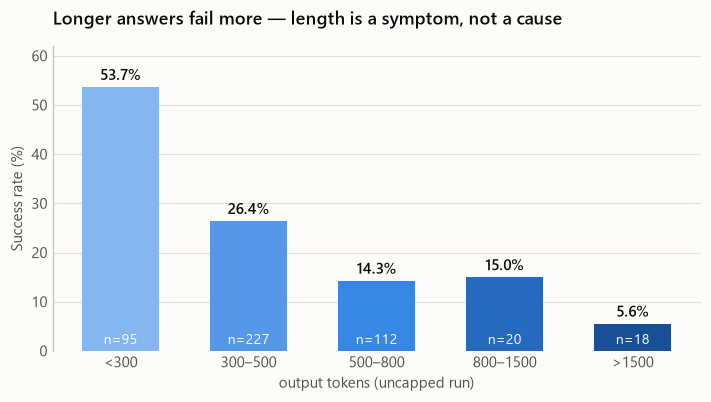

In [5]:
BINS = [(0, 300), (300, 500), (500, 800), (800, 1500), (1500, 10**9)]
BIN_LABEL = ["<300", "300–500", "500–800", "800–1500", ">1500"]

stats = []
for lo, hi in BINS:
    sub = [i for i in ids if lo <= gen_nocap[i]["usage"]["output_tokens"] < hi]
    p = sum(ok(st_nocap, i) for i in sub)
    stats.append((len(sub), p / len(sub) * 100 if sub else 0))

x = np.arange(len(BINS))
fig, ax = plt.subplots(figsize=(7.6, 3.6))
bars = ax.bar(x, [s[1] for s in stats], 0.6, color=SEQ)
for bar, (n, sr) in zip(bars, stats):
    ax.text(bar.get_x() + bar.get_width() / 2, sr + 1.4, f"{sr:.1f}%",
            ha="center", fontsize=10, color=INK, fontweight="600")
    ax.text(bar.get_x() + bar.get_width() / 2, 1.4, f"n={n}",
            ha="center", fontsize=9, color=SURFACE)

ax.set_xticks(x, BIN_LABEL)
ax.set_xlabel("output tokens (uncapped run)")
ax.set_ylabel("Success rate (%)")
ax.set_ylim(0, 62)
ax.set_title("Longer answers fail more — length is a symptom, not a cause")
frame(ax, xgrid=False)
save(fig, "fig03_length_vs_sr")
plt.show()

## Fig 4 — The cap, paired per instance

Aggregate rates hide direction of change, so this counts the two directions separately.
Polarity is the job → the diverging pair (blue gain / red loss) with the two arms read
against a zero line.

The reference bar is the run-to-run noise floor, measured on the 330 instances the cap
could not have touched: those still moved by 4 instances at `temperature=0`. Any net
smaller than that is unreadable.

findfont: Failed to find font weight 600, now using 700.


findfont: Failed to find font weight 600, now using 700.


saved -> analysis/figures/fig04_cap_paired.png


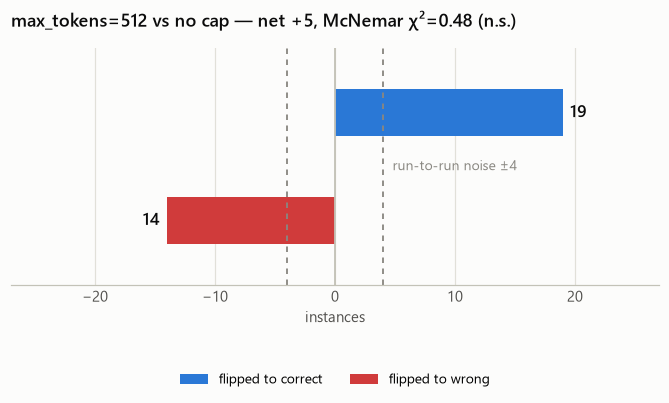

In [6]:
gained = [i for i in ids if not ok(st_nocap, i) and ok(st_cap, i)]
lost = [i for i in ids if ok(st_nocap, i) and not ok(st_cap, i)]

unaffected = [i for i in ids if gen_nocap[i]["usage"]["output_tokens"] <= 512]
noise = abs(sum(ok(st_cap, i) for i in unaffected) - sum(ok(st_nocap, i) for i in unaffected))

n_mc = len(gained) + len(lost)
chi2 = (abs(len(gained) - len(lost)) - 1) ** 2 / n_mc if n_mc else 0.0

fig, ax = plt.subplots(figsize=(7.6, 2.8))
ax.barh([1], [len(gained)], 0.44, color=S1, label="flipped to correct")
ax.barh([0], [-len(lost)], 0.44, color=STATUS_CRIT, label="flipped to wrong")
ax.text(len(gained) + 0.6, 1, f"{len(gained)}", va="center", fontsize=11, color=INK, fontweight="600")
ax.text(-len(lost) - 0.6, 0, f"{len(lost)}", va="center", ha="right", fontsize=11, color=INK, fontweight="600")

for s in (noise, -noise):
    ax.axvline(s, color=MUTED, ls=(0, (3, 3)), lw=1.2)
# The annotation goes in the empty band between the two bars. Placed above the top
# bar it collided with the title.
ax.text(noise + 0.8, 0.5, f"run-to-run noise ±{noise}", fontsize=9, color=MUTED, va="center")
ax.axvline(0, color=BASELINE, lw=1.2)

ax.set_yticks([0, 1], ["", ""])
ax.set_ylim(-0.6, 1.6)
ax.set_xlabel("instances")
lim = max(len(gained), len(lost)) + 8
ax.set_xlim(-lim, lim)
ax.set_title(f"max_tokens=512 vs no cap — net {len(gained)-len(lost):+d}, McNemar χ²={chi2:.2f} (n.s.)")
# Legend below the axis: inside the frame it sat on top of the negative bar.
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.32), ncols=2)
frame(ax)
save(fig, "fig04_cap_paired")
plt.show()

## Fig 5 — Where success rate varies most

Ranking is the job, so a sorted horizontal bar with the label beside each mark. Databases
with fewer than 5 instances are dropped — at n<5 a single instance moves the rate by 20+
points and the ordering stops meaning anything.

The spread across databases *inside* one dialect is wider than the spread across dialects,
which is the point: schema difficulty dominates dialect.

saved -> analysis/figures/fig05_sr_by_database.png


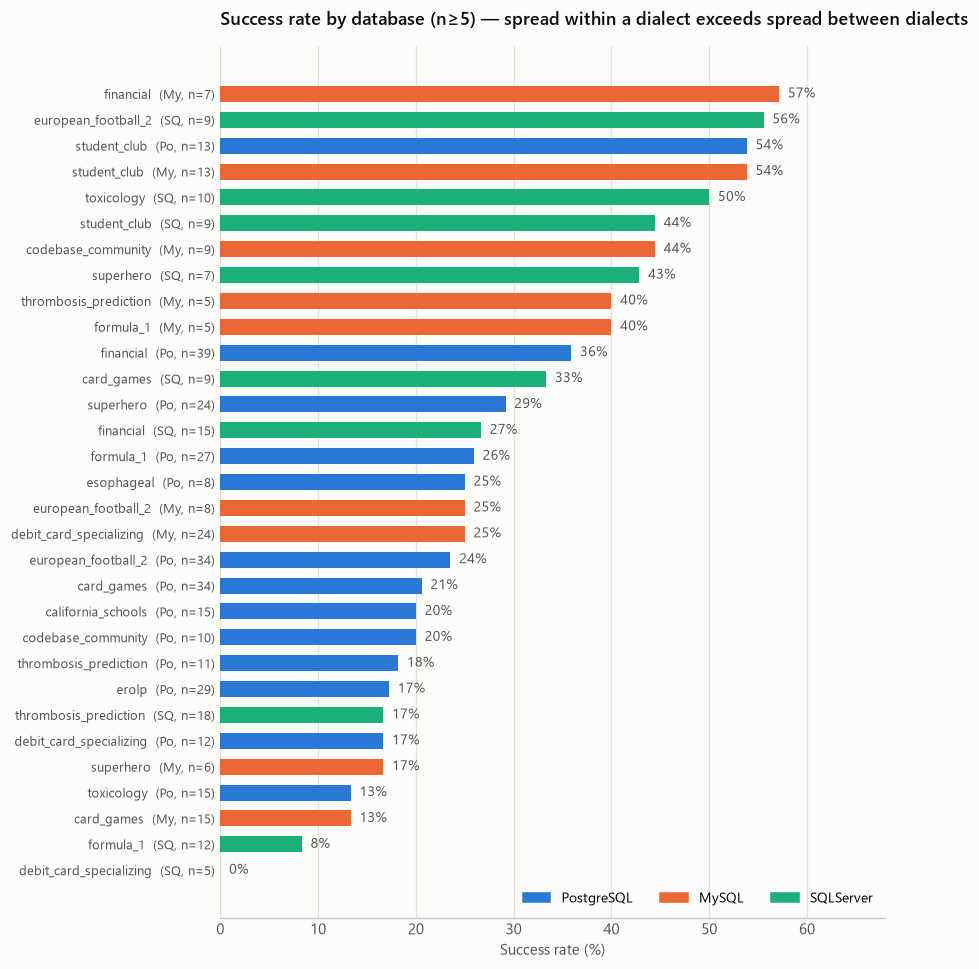

In [7]:
by_db = {}
for i in ids:
    g = gen_nocap[i]
    by_db.setdefault((g["dialect"], g["db_id"]), []).append(i)

MIN_N = 5
recs = []
for (d, db), members in by_db.items():
    if len(members) < MIN_N:
        continue
    p = sum(ok(st_nocap, i) for i in members)
    recs.append((f"{db}  ({d[:2]}, n={len(members)})", p / len(members) * 100, d))
recs.sort(key=lambda r: r[1])

colour = {"PostgreSQL": S1, "MySQL": S2, "SQLServer": S3}
y = np.arange(len(recs))
fig, ax = plt.subplots(figsize=(7.8, 0.29 * len(recs) + 1.3))
bars = ax.barh(y, [r[1] for r in recs], 0.62, color=[colour[r[2]] for r in recs])
for bar, r in zip(bars, recs):
    ax.text(bar.get_width() + 0.9, bar.get_y() + bar.get_height() / 2,
            f"{r[1]:.0f}%", va="center", fontsize=9, color=INK_2)

ax.set_yticks(y, [r[0] for r in recs], fontsize=8.5)
ax.set_xlabel("Success rate (%)")
ax.set_xlim(0, 68)
ax.set_title(f"Success rate by database (n≥{MIN_N}) — spread within a dialect exceeds spread between dialects")
handles = [plt.Rectangle((0, 0), 1, 1, color=colour[d]) for d in DIALECTS]
ax.legend(handles, DIALECTS, loc="lower right", ncols=3)
frame(ax)
save(fig, "fig05_sr_by_database")
plt.show()

## Fig 6 — Repair loop: the lift, and what it cost

Two measures on different scales (percentage points and token count). They go in **two
panels sharing nothing**, never one chart with two y-axes — a dual axis lets the author
choose the apparent relationship by picking scales.

The loop is the *blind* condition: it sees execution output but no localization signal. It
is the baseline any attribution-guided method has to beat, not a proposed method.

saved -> analysis/figures/fig06_loop_lift_and_cost.png


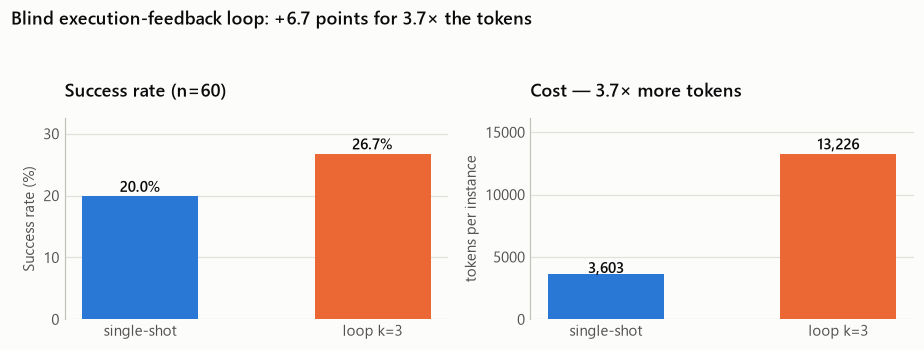

In [8]:
LOOP = BASE / "data" / "outputs" / "loop_k3_pg60"
traj = {r["instance_id"]: r for r in jsonl(LOOP / "pg.jsonl")}
st_loop = {r["instance_id"]: r.get("status")
           for r in jsonl(LOOP / "loop_postgresql_output_with_status.jsonl")}

lids = sorted(set(st_loop) & set(st_nocap))
s_pass = sum(ok(st_nocap, i) for i in lids)
l_pass = sum(ok(st_loop, i) for i in lids)

tok_single = np.mean([gen_nocap[i]["usage"]["total_tokens"] for i in lids])
tok_loop = np.mean([traj[i]["usage"]["total_tokens"] for i in lids if i in traj])

fig, (axL, axR) = plt.subplots(1, 2, figsize=(8.4, 3.2), gridspec_kw={"width_ratios": [1, 1]})

for ax, vals, ylab, title, fmt in (
    (axL, [s_pass / len(lids) * 100, l_pass / len(lids) * 100], "Success rate (%)",
     f"Success rate (n={len(lids)})", "{:.1f}%"),
    (axR, [tok_single, tok_loop], "tokens per instance",
     f"Cost — {tok_loop/tok_single:.1f}× more tokens", "{:,.0f}"),
):
    bars = ax.bar([0, 1], vals, 0.5, color=[S1, S2])
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, v * 1.03, fmt.format(v),
                ha="center", fontsize=10, color=INK, fontweight="600")
    ax.set_xticks([0, 1], ["single-shot", "loop k=3"])
    ax.set_ylabel(ylab)
    ax.set_ylim(0, max(vals) * 1.22)
    ax.set_title(title)
    frame(ax, xgrid=False)

fig.suptitle("Blind execution-feedback loop: +%.1f points for %.1f× the tokens"
             % ((l_pass - s_pass) / len(lids) * 100, tok_loop / tok_single),
             x=0.005, ha="left", fontsize=12, fontweight="600", color=INK)
fig.tight_layout(rect=(0, 0, 1, 0.92))
save(fig, "fig06_loop_lift_and_cost")
plt.show()

## Fig 7 — Blind iteration also destroys correct answers

The aggregate lift nets out two opposite movements. Splitting them is what turns "the loop
helps a bit" into "the loop helps some instances and wrecks others" — the second reading is
the one that motivates knowing *where* to intervene before intervening.

Status colours (good / critical) rather than categorical hues, because these two bars are
states, not series — and they ship with labels, never colour alone.

saved -> analysis/figures/fig07_loop_gain_vs_damage.png


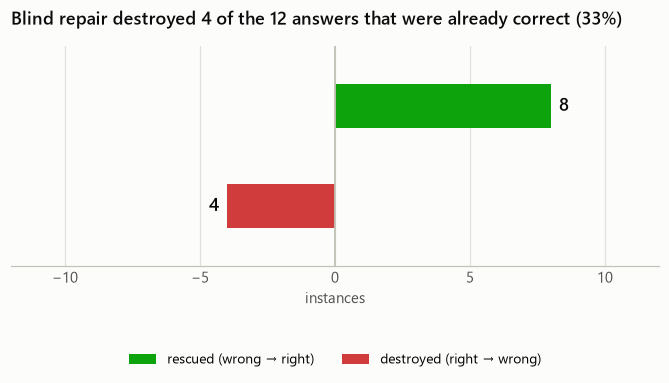

In [9]:
g = [i for i in lids if not ok(st_nocap, i) and ok(st_loop, i)]
b = [i for i in lids if ok(st_nocap, i) and not ok(st_loop, i)]
was_right = sum(ok(st_nocap, i) for i in lids)

fig, ax = plt.subplots(figsize=(7.6, 2.6))
ax.barh([1], [len(g)], 0.44, color=STATUS_GOOD, label="rescued (wrong → right)")
ax.barh([0], [-len(b)], 0.44, color=STATUS_CRIT, label="destroyed (right → wrong)")
ax.text(len(g) + 0.3, 1, f"{len(g)}", va="center", fontsize=12, color=INK, fontweight="600")
ax.text(-len(b) - 0.3, 0, f"{len(b)}", va="center", ha="right", fontsize=12, color=INK, fontweight="600")
ax.axvline(0, color=BASELINE, lw=1.2)

ax.set_yticks([0, 1], ["", ""])
ax.set_ylim(-0.6, 1.6)
ax.set_xlabel("instances")
lim = max(len(g), len(b)) + 4
ax.set_xlim(-lim, lim)
ax.set_title(f"Blind repair destroyed {len(b)} of the {was_right} answers that were already correct "
             f"({len(b)/was_right*100:.0f}%)")
# Below the axis, same reason as Fig 4.
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.34), ncols=2)
frame(ax)
save(fig, "fig07_loop_gain_vs_damage")
plt.show()

## Fig 8 — Execution feedback pays off unevenly

The central figure. Instances are split by *how the single-shot attempt failed*, then the
loop's recovery rate is measured within each group.

When the database names the defect (`operator does not exist: date - bigint`) the loop has
something to act on. When the SQL runs and only a hidden test case disagrees, there is no
signal at all — and that silent group is the larger one. It is also precisely where a
localization signal would have to earn its keep.

PostgreSQL only: it is the one dialect for which upstream labels every failure's phase.

saved -> analysis/figures/fig08_asymmetry_by_failure_class.png


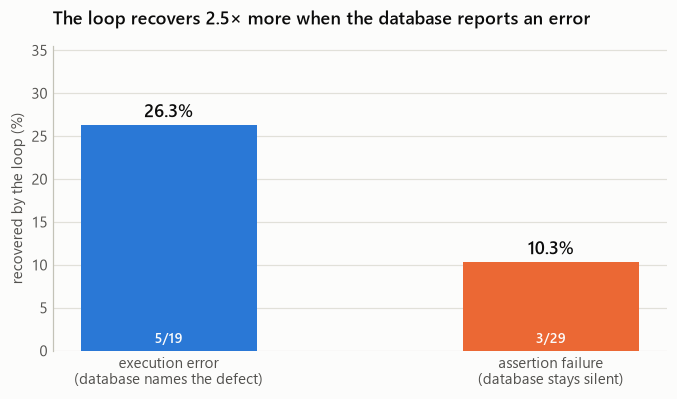

n is small (19 and 29) — direction is suggestive, not established.


In [10]:
groups = []
for cls, nice in (("execution", "execution error\n(database names the defect)"),
                  ("assertion", "assertion failure\n(database stays silent)")):
    sub = [i for i in lids if not ok(st_nocap, i) and phase_nocap.get(i) == cls]
    rec = sum(ok(st_loop, i) for i in sub)
    groups.append((nice, len(sub), rec, rec / len(sub) * 100 if sub else 0))

x = np.arange(len(groups))
fig, ax = plt.subplots(figsize=(7.2, 3.6))
bars = ax.bar(x, [gp[3] for gp in groups], 0.46, color=[S1, S2])
for bar, gp in zip(bars, groups):
    ax.text(bar.get_x() + bar.get_width() / 2, gp[3] + 0.9, f"{gp[3]:.1f}%",
            ha="center", fontsize=12, color=INK, fontweight="600")
    ax.text(bar.get_x() + bar.get_width() / 2, 0.9, f"{gp[2]}/{gp[1]}",
            ha="center", fontsize=9, color=SURFACE, fontweight="600")

ax.set_xticks(x, [gp[0] for gp in groups], fontsize=9.5)
ax.set_ylabel("recovered by the loop (%)")
ax.set_ylim(0, max(gp[3] for gp in groups) * 1.35)
ratio = groups[0][3] / groups[1][3] if groups[1][3] else float("nan")
ax.set_title(f"The loop recovers {ratio:.1f}× more when the database reports an error")
frame(ax, xgrid=False)
save(fig, "fig08_asymmetry_by_failure_class")
plt.show()

print("n is small (%d and %d) — direction is suggestive, not established."
      % (groups[0][1], groups[1][1]))

## Fig 9 — Do the later rounds do anything?

A go/no-go check rather than a result. If the submitted answer never changed after round 1,
the trajectory has no step structure and step-level attribution would have nothing to
attribute over.

Read it with care in the other direction too: mass on the final round means the answer was
*still moving* when the budget ran out, which is consistent with converging late and
equally consistent with thrashing. These data do not separate the two.

saved -> analysis/figures/fig09_settled_round.png


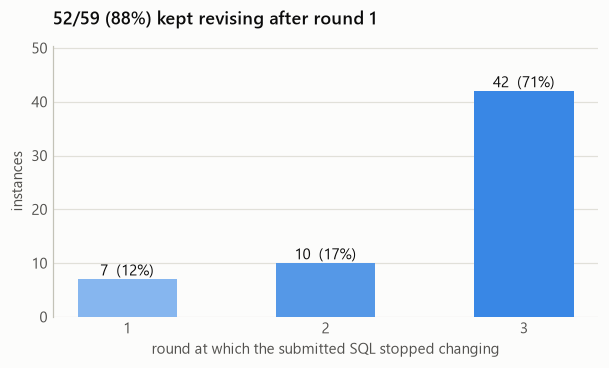

In [11]:
settled = Counter(traj[i]["settled_round"] for i in traj)
ks = sorted(settled)
vals = [settled[k] for k in ks]
total = sum(vals)

fig, ax = plt.subplots(figsize=(6.4, 3.2))
bars = ax.bar([str(k) for k in ks], vals, 0.5, color=SEQ[: len(ks)])
for bar, v in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 0.7,
            f"{v}  ({v/total*100:.0f}%)", ha="center", fontsize=10, color=INK)

ax.set_xlabel("round at which the submitted SQL stopped changing")
ax.set_ylabel("instances")
ax.set_ylim(0, max(vals) * 1.2)
changed = total - settled.get(1, 0)
ax.set_title(f"{changed}/{total} ({changed/total*100:.0f}%) kept revising after round 1")
frame(ax, xgrid=False)
save(fig, "fig09_settled_round")
plt.show()

## Fig 10 — What the execution errors actually are

Ranking again, so sorted horizontal bars.

**Read this one with the caveat attached.** The failure *set* comes from the harness and the
error *text* comes from replaying each prediction against the real database, but the
**categories are ours** — BIRD-CRITIC ships no error taxonomy. The `other` bucket is large,
which means the rules under-cover; and the grouping used in prose elsewhere ("type
reasoning ≈ 34%") merges three of these buckets by hand and is not reproducible from this
cell. For a paper this needs the rules written into code and two independent annotators.

PostgreSQL only, for the same labelling reason as Fig 8.

saved -> analysis/figures/fig10_error_taxonomy_pg.png


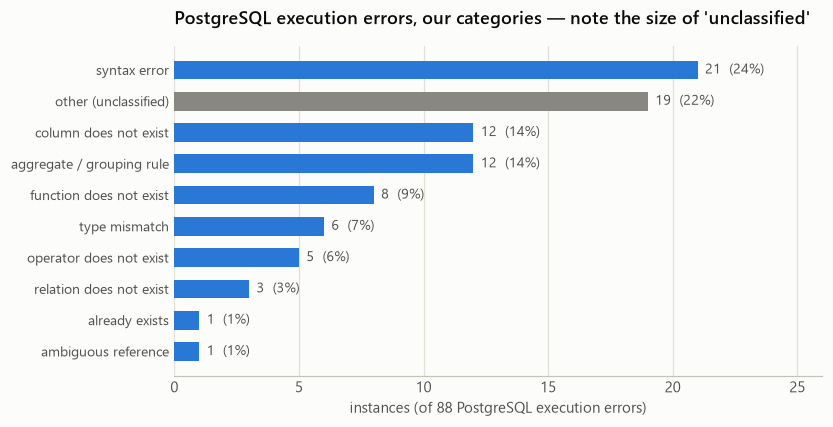

In [12]:
# Counts as produced by scripts/err_probe.py on 2026-08-12, run with nothing else
# touching the database. Kept as literals because the replay needs the evaluation
# container; re-running it concurrently with anything else yields phantom errors
# (dropped ephemeral databases, deadlocks) rather than model failures.
TAXONOMY = [
    ("syntax error", 21),
    ("other (unclassified)", 19),
    ("aggregate / grouping rule", 12),
    ("column does not exist", 12),
    ("function does not exist", 8),
    ("type mismatch", 6),
    ("operator does not exist", 5),
    ("relation does not exist", 3),
    ("ambiguous reference", 1),
    ("already exists", 1),
]
N_EXEC = sum(v for _, v in TAXONOMY)

recs = sorted(TAXONOMY, key=lambda r: r[1])
y = np.arange(len(recs))
colors = [MUTED if "unclassified" in n else S1 for n, _ in recs]

fig, ax = plt.subplots(figsize=(7.6, 3.9))
bars = ax.barh(y, [r[1] for r in recs], 0.6, color=colors)
for bar, r in zip(bars, recs):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
            f"{r[1]}  ({r[1]/N_EXEC*100:.0f}%)", va="center", fontsize=9, color=INK_2)

ax.set_yticks(y, [r[0] for r in recs], fontsize=9)
ax.set_xlabel(f"instances (of {N_EXEC} PostgreSQL execution errors)")
ax.set_xlim(0, 26)
ax.set_title("PostgreSQL execution errors, our categories — note the size of 'unclassified'")
frame(ax)
save(fig, "fig10_error_taxonomy_pg")
plt.show()

## Table view

Present so no figure is the only route to its numbers — required whenever a fill sits below
3:1 against the surface, and useful regardless.

In [13]:
print(f"{'':<14}{'n':>5}{'no cap':>10}{'cap 512':>10}{'exec err':>10}{'assert':>9}")
print("-" * 58)
for d in DIALECTS:
    a, c = report_totals(NOCAP, d), report_totals(CAP, d)
    print(f"{d:<14}{a['n']:>5}{a['accuracy']:>9.2f}%{c['accuracy']:>9.2f}%"
          f"{a['execution']:>10}{a['assertion']:>9}")
tn = sum(report_totals(NOCAP, d)["n"] for d in DIALECTS)
print("-" * 58)
print(f"{'TOTAL':<14}{tn:>5}{sum(ok(st_nocap,i) for i in ids)/len(ids)*100:>9.2f}%"
      f"{sum(ok(st_cap,i) for i in ids)/len(ids)*100:>9.2f}%"
      f"{sum(report_totals(NOCAP,d)['execution'] for d in DIALECTS):>10}"
      f"{sum(report_totals(NOCAP,d)['assertion'] for d in DIALECTS):>9}")

print("\nRepair loop, PostgreSQL subset")
print("-" * 58)
print(f"  paired instances        {len(lids)}")
print(f"  single-shot             {s_pass}/{len(lids)} = {s_pass/len(lids)*100:.1f}%")
print(f"  loop k=3                {l_pass}/{len(lids)} = {l_pass/len(lids)*100:.1f}%")
print(f"  rescued / destroyed     {len(g)} / {len(b)}")
print(f"  tokens per instance     {tok_single:,.0f} -> {tok_loop:,.0f}  ({tok_loop/tok_single:.1f}x)")
for nice, n_, rec, pct in groups:
    print(f"  recovered, {nice.splitlines()[0]:<18} {rec}/{n_} = {pct:.1f}%")

                  n    no cap   cap 512  exec err   assert
----------------------------------------------------------
PostgreSQL      276    25.00%    26.81%        88      117
MySQL            98    33.67%    33.67%        24       41
SQLServer        98    29.59%    29.59%        24       45
----------------------------------------------------------
TOTAL           472    27.75%    28.81%       136      203

Repair loop, PostgreSQL subset
----------------------------------------------------------
  paired instances        60
  single-shot             12/60 = 20.0%
  loop k=3                16/60 = 26.7%
  rescued / destroyed     8 / 4
  tokens per instance     3,603 -> 13,226  (3.7x)
  recovered, execution error    5/19 = 26.3%
  recovered, assertion failure  3/29 = 10.3%


## What these figures do and do not support

Supported by the data as plotted:

- The undocumented 512-token cap truncates ~30% of answers and does **not** move success
  rate beyond run-to-run noise (Fig 1, 4).
- Assertion failures outnumber execution errors roughly 3:2 (Fig 2).
- Success rate falls monotonically with answer length (Fig 3).
- Variation across databases exceeds variation across dialects (Fig 5).
- A blind execution-feedback loop lifts success rate while destroying a substantial share of
  answers that were already correct (Fig 6, 7).
- The loop's benefit concentrates on failures the database reports (Fig 8).

Not supported, and stated here so the figures are not over-read:

- Nothing about **Oracle** — 98 instances were never run.
- Nothing comparable to the **leaderboard** — different n, different model, different
  environment.
- Fig 8's asymmetry rests on 19 and 29 instances. The direction is consistent with the
  mechanism; the magnitude is not pinned down.
- Fig 9 cannot distinguish late convergence from thrashing.
- Fig 10's categories are ours, and its `other` bucket is large enough that the ranking
  below the top few buckets is not solid.
- The loop grading was run when 4 of 60 instances had been disturbed by concurrent database
  access; those instances were dropped from the trajectory file but the grading predates the
  cleanup, so loop numbers carry ±4 instances of slack on top of ordinary noise.